# Obtenemos datos desde una API pública

In [10]:
import requests
import pandas as pd

In [11]:
def get_historic_price(symbol, after='2018-09-01'):
    
    url = 'https://api.kraken.com/0/public/OHLC'
    pair = f"{symbol.upper()}USD" # XBTUSD when symbol='xbt' for example
    
    resp = requests.get(url, params={
        "pair": pair,
        'interval': 60,
        'since': str(int(pd.Timestamp(after).timestamp()))
    })
    resp.raise_for_status()
    
    data = resp.json()
    
    results_key = [k for k in data['result'].keys() if k != 'last'][0]
    results = [
        (close_time, float(open), float(high), float(low), float(close), float(volume))
        for (close_time, open, high, low, close, vwap, volume, count)
        in data['result'][results_key]
    ]
    df = pd.DataFrame(results, columns=[
        'CloseTime', 'OpenPrice', 'HighPrice', 'LowPrice', 'ClosePrice', 'Volume'
    ])
    df['CloseTime'] = pd.to_datetime(df['CloseTime'], unit='s')
    df.set_index('CloseTime', inplace=True)
    return df

### Calculamos la fecha y hora exactas de hace 7 días respecto al momento actual
- pd.Timestamp.now() - Devuelve la hora y fecha actuales
- pd.offsets.Day(7) - Representa un desplazamiento de 7 días

In [12]:
last_week = (pd.Timestamp.now() - pd.offsets.Day(7))
last_week

Timestamp('2026-04-29 13:11:18.746124')

### A continuación vamos a obtener el precio del bitcoin y ether de una semana entera

In [13]:
btc = get_historic_price('btc', after=last_week)

In [14]:
eth = get_historic_price('eth', after=last_week)

La función **head** muestra las primeras filas del DataFrame *btc* por defecto muestra 5 filas

In [11]:
btc.head()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
CloseTime,,,,,
2026-01-14 22:00:00,97546.3,97567.0,96808.5,96904.4,157.213859
2026-01-14 23:00:00,96904.5,97359.0,96896.6,96933.3,32.537185
2026-01-15 00:00:00,96933.4,96983.6,96500.0,96624.7,37.680553
2026-01-15 01:00:00,96624.8,96950.1,96311.6,96437.7,34.343283
2026-01-15 02:00:00,96437.8,96570.1,96050.0,96299.9,54.551081


La siguiente sentencia genera una gráfica de serie temporal del precio de cierre **ClosePrice** del bitcoin usando Pandas y Matplotlib
- **btc['ClosePrice']**: Accede a la columna ClosePrice del DataFrame btc, esto devuelve una serie de pandas con precios de cierre
- **.plot()**: Método de Panda para crear gráficos, por defecto genera un gráfico de linea
- **figsize=(15,7)**: Parámetro que define el tamaño de la figuar 15 pulgadas de ancho por 7 pulgadas de alto

<Axes: xlabel='CloseTime'>

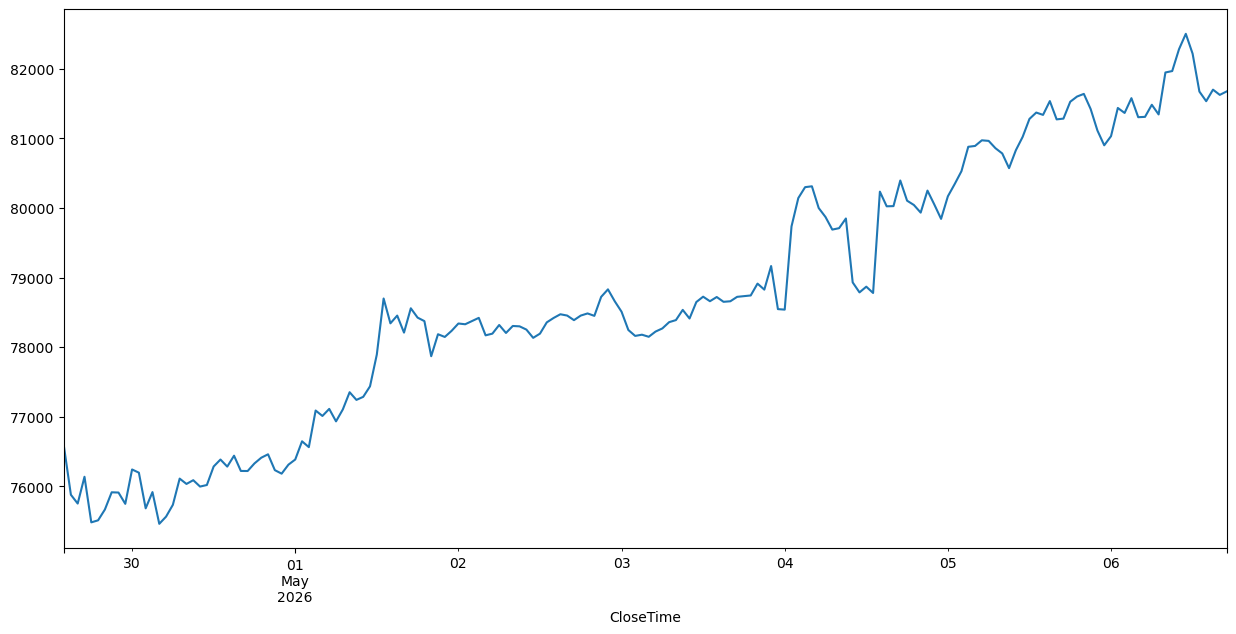

In [15]:
btc['ClosePrice'].plot(figsize=(15, 7))

La función **describe()** genera estadísticas descriptivas resumidas de un DataFrame o Series de pandas

Produce un resumen estadístico que incluye medidas de tendencia central, dispersión y distribución de datos númericos

- **count:** Número de valores no nulos
- **mean:** Promedio (media aritmética)
- **std:** Desviación estándar (dispersión)
- **min:** Valor minimo
- **25%:** Primer cuartil (percentil 25)
- **50%:** Mediana (percentil 50)
- **75%:** Tercer cuartil (percentil 75)
- **max:** Valor maximo

**Para columnas categóricas (string) si las hay:** count, unique, top, freq

In [13]:
btc.describe()

,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume
count,172.000000,172.000000,172.000000,172.000000,172.000000
mean,93575.150000,93763.783140,93309.850581,93531.405814,74.704092
std,2603.612624,2525.906695,2683.359574,2599.462452,99.494211
min,87533.800000,88047.200000,87200.000000,87533.400000,2.177919
25%,91469.825000,91502.850000,91090.825000,91187.950000,19.089863
50%,95055.450000,95146.350000,94952.550000,95055.450000,36.703727
75%,95408.625000,95533.775000,95254.150000,95406.800000,94.141611
max,97546.300000,97567.000000,96896.600000,97030.600000,729.165477


### Exportar datos a excel

Jupyter notebooks trabaja muy bien con archivos Excel

In [16]:
writer = pd.ExcelWriter('cryptos.xlsx')

Si la linea de código anterior no funciona, abrir miniconda como administrador y ejecutar el comando
~~~
conda install openpyxl
~~~

Ahora escribiremos los datos de Ether y Bitcoin den hojas separadas

In [17]:
btc.to_excel(writer, sheet_name='Bitcoin')
eth.to_excel(writer, sheet_name='Ether')

In [19]:
writer.close()